# Part A : Change of Coordinates

This notebook explores the fundamental concepts of change of coordinates and linear transformations using Python's NumPy and Matplotlib libraries. We will define vectors, transform them between different coordinate systems (bases), and visualize the effects of linear transformations on a grid.

## 1. Importing Necessary Libraries

We begin by importing the required Python libraries:
- `numpy` for numerical operations, especially with arrays and matrices.
- `matplotlib.pyplot` for creating static, interactive, and animated visualizations in Python.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Defining a Vector `v`

In linear algebra, a **vector** is a mathematical object that has both magnitude and direction. In a 2D space, it can be represented as a column matrix with two components, say $(x, y)$.

Here, we define our vector `v` as a 2x1 NumPy array.

### Explanation of `np.array`

`np.array()` is a fundamental function in the NumPy library used to create arrays. When you pass a list of lists (e.g., `[[3],[2]]`), it creates a 2D array (a matrix) where each inner list represents a row. In this case, `[[3],[2]]` creates a column vector `[[3],[2]]` with shape (2,1).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Define vector v as a 2x1 column matrix
v = np.array([[3],[2]])
print(f"Vector v = \n{v} with size {v.shape[0]} X {v.shape[1]}\n")

Vector v = 
[[3]
 [2]] with size 2 X 1



## 3. Defining the New Basis `B` and Coordinate Change Matrix `S`

A **basis** for a vector space is a set of linearly independent vectors that can be used to represent any other vector in that space as a unique linear combination. The standard basis in 2D is usually composed of `e1= [1, 0]^T` and `e2 = [0, 1]^T`.

A **coordinate change matrix** (or transformation matrix) `S` is formed by placing the basis vectors of the new basis as its columns. If we have a new basis `B = {b1, b2}`, then `S = [b1 | b2]`.

In our case, the basis vectors are `b1 = [1, -1]^T` and `b2 = [1, 1]^T`.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the new basis B. The columns of 's' are the new basis vectors.
# s[0] is the first basis vector [1, -1]
# s[1] is the second basis vector [1, 1]

s = np.array([[1,1],[-1,1]])
print(f"Coordinate Change Matrix S = \n{s} with size {s.shape[0]} X {s.shape[1]}\n")

Coordinate Change Matrix S = 
[[ 1  1]
 [-1  1]] with size 2 X 2



## 4. Computing the Inverse of `S` (`S^-1`)

To find the coordinates of a vector `v` in a new basis `B`, we use the inverse of the coordinate change matrix `S`. If `v` is a vector in the standard basis, and `[v]_B` are its coordinates in basis `B`, then $S^{-1}$.

### Explanation of `np.linalg.inv`

`np.linalg.inv()` is a NumPy function that computes the multiplicative inverse of a matrix. For a square matrix `S`, its inverse `S^-1` satisfies the property `S @ S^-1 = I` (identity matrix).

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Compute the inverse of the coordinate change matrix S
s = np.array([[1,1],[-1,1]])
s_inv = np.linalg.inv(s)
print(f"Matrix S_inv = \n{s_inv} with size {s_inv.shape[0]} X {s_inv.shape[1]}\n")
print(f"Check S * S_inv = \n{np.dot(s, s_inv)}\n")

Matrix S_inv = 
[[ 0.5 -0.5]
 [ 0.5  0.5]] with size 2 X 2

Check S * S_inv = 
[[1. 0.]
 [0. 1.]]



## 5. Finding Coordinates of `v` in Basis `B`

To convert a vector from the standard basis to a new basis `B`, we multiply it by the inverse of the coordinate change matrix `S`. This operation gives us the components of the original vector with respect to the new basis vectors.

### Explanation of the `@` operator

The `@` operator in Python  is used for matrix multiplication. It performs the dot product for 2D arrays (matrices). So, `A @ B` means matrix multiplication of `A` and `B`.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate the coordinates of vector v in the new basis B
# This is done by multiplying the inverse of S with v

v = np.array([[3],[2]])
s = np.array([[1,1],[-1,1]])
s_inv = np.linalg.inv(s)
v_new = s_inv @ v
print(f"Coordinates of v in basis B = \n{v_new} with size {v_new.shape[0]} X {v_new.shape[1]}\n")

Coordinates of v in basis B = 
[[0.5]
 [2.5]] with size 2 X 1



## 6. Verifying Reconstruction of the Vector

After finding the coordinates of `v` in the new basis `B`, we can reconstruct the original vector `v` by multiplying the coordinate change matrix `S` with the new coordinates `[v]_B`. This should ideally yield the original vector `v`.

Mathematically, `v = S @ [v]_B`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Reconstruct the original vector v from its new coordinates and the basis matrix S

v = np.array([[3],[2]])
s = np.array([[1,1],[-1,1]])
s_inv = np.linalg.inv(s)
v_new = s_inv @ v
v_reconstructed = s @ v_new

print("\nReconstructed vector:")
print(v_reconstructed)


# # Calculate the Euclidean norm of the difference between the original and reconstructed vectors
# # A value close to zero indicates successful reconstruction
# error = np.linalg.norm(v - v_reconstructed)

# print("\nReconstruction Error:")
# print(error)


Reconstructed vector:
[[3.]
 [2.]]

Reconstruction Error:
0.0


## 7. Visualization of Vector in Standard Basis and New Basis

To effectively understand the change of coordinates, we will visualize our vector `v` in two different representations: first in the familiar **standard basis**, and then in our **new basis B**.

### Standard Basis Representation

The standard basis in a 2D Cartesian coordinate system consists of two orthogonal unit vectors: `e1 = [1, 0]^T` along the x-axis and <br>`e2 = [0, 1]^T` along the y-axis. Any vector `v = [x, y]^T` can be uniquely represented as `x*e1 + y*e2`.

### New Basis Representation

After finding the coordinates `[v]_B = [c1, c2]^T` of `v` in the new basis `B = {b1, b2}`, this representation means that the original vector `v` can be formed by `c1` times the first basis vector `b1` plus `c2` times the second basis vector `b2` (i.e., `v = c1*b1 + c2*b2`). In this section, we will visualize these new basis vectors and the coordinates `[v]_B` that represent `v` within this new framework.

### Explanation of `plt.subplots`, `quiver`, `set_aspect('equal')` , `axvline()` and `axhline()`

- `plt.subplots(1, 2, figsize=(12, 5))`: This function from Matplotlib creates a figure and a grid of subplots. Here, `(1, 2)` means one row and two columns, which is perfect for comparing our two visualizations side-by-side. The `figsize` argument controls the overall size of the figure.

- `axs[index].quiver(X, Y, U, V, ...)`: This is the primary function for plotting vectors as arrows. `(X, Y)` specify the starting point of the arrow (usually the origin `(0,0)`), and `(U, V)` represent the components of the vector (the direction and magnitude). Key parameters for our visualizations include:
    - `angles='xy'`: Ensures the arrow angles are interpreted correctly based on the x and y data coordinates.
    - `scale_units='xy'` and `scale=1`: These work together to ensure that the length of the arrow accurately reflects the magnitude of the vector in data units, preventing distortion.

- `axs[index].set_aspect('equal')`: This crucial command forces the scaling of the x-axis and y-axis to be the same. Without it, the visual representation of vectors can be distorted, making it difficult to accurately perceive lengths, angles, and orthogonality. By setting the aspect ratio to 'equal', we ensure that our geometric interpretations are correct.

- `axvline(x=value)` draws a vertical line at a specified x-coordinate across the entire axes. Similarly, `axhline(y=value)` draws a horizontal line. These are used here to emphasize the x and y axes.


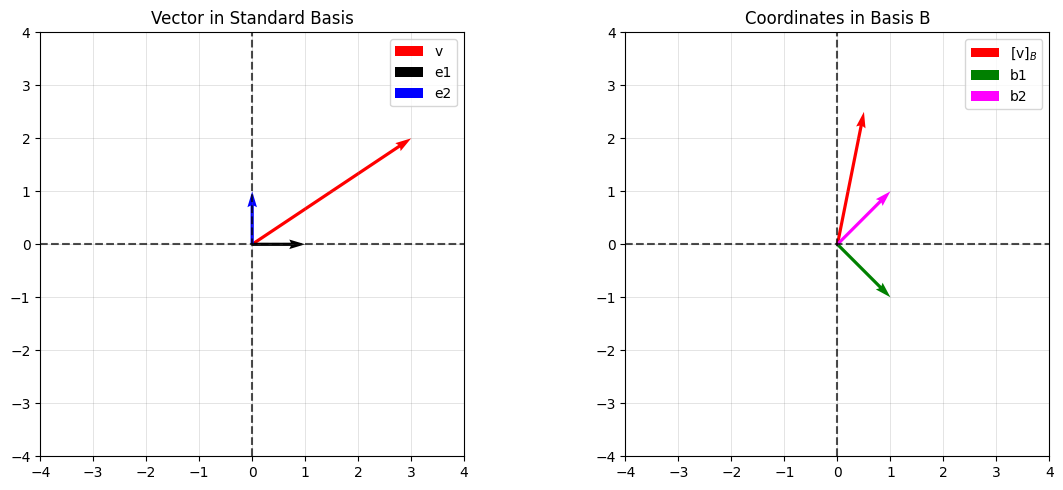

In [7]:
import numpy as np
import matplotlib.pyplot as plt

v = np.array([[3],[2]])
s = np.array([[1,1],[-1,1]])
s_inv = np.linalg.inv(s)
v_new = s_inv @ v

# Create a figure with two subplots side-by-side for visualization

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: Standard Basis Representation

v = np.array([[3],[2]])

# Plot vector v in the standard basis (red arrow)
axs[0].quiver(0, 0, v[0], v[1],
              angles='xy',
              scale_units='xy',
              scale=1,
              color='red',
              label='v')

# Plot standard basis vector e1 (black arrow)
axs[0].quiver(0, 0, 1, 0,
              angles='xy',
              scale_units='xy',
              scale=1,
              color='black',
              label='e1')

# Plot standard basis vector e2 (blue arrow)
axs[0].quiver(0, 0, 0, 1,
              angles='xy',
              scale_units='xy',
              scale=1,
              color='blue',
              label='e2')

# Add dashed lines for x and y axes
axs[0].axvline(x=0,
               linestyle='--',
               color='black',
               alpha=0.7)

axs[0].axhline(y=0,
               linestyle='--',
               color='black',
               alpha=0.7)

axs[0].set_title("Vector in Standard Basis")

# Set x and y axis limits for better visualization
axs[0].set_xlim(-4, 4)
axs[0].set_ylim(-4, 4)

axs[0].grid(True, color='gray', linewidth=0.5, alpha=0.3) # Add a grid to the plot
axs[0].legend() # Display the legend for vectors
axs[0].set_aspect('equal') # Ensure equal scaling for axes



# Subplot 2: New Basis Representation

# Plot the coordinate vector [v]_B in the new basis (red arrow)
axs[1].quiver(0, 0, v_new[0], v_new[1],
              angles='xy',
              scale_units='xy',
              scale=1,
              color='red',
              label='[v]$_B$')

# Plot the first basis vector b1 from matrix S (green arrow)
axs[1].quiver(0, 0, s[0][0], s[1][0],
              angles='xy',
              scale_units='xy',
              scale=1,
              color='green',
              label='b1')

# Plot the second basis vector b2 from matrix S (magenta arrow)
axs[1].quiver(0, 0, s[0][1], s[1][1],
              angles='xy',
              scale_units='xy',
              scale=1,
              color='magenta',
              label='b2')

# Add dashed lines for x and y axes
axs[1].axvline(x=0,
               linestyle='--',
               color='black',
               alpha=0.7)

axs[1].axhline(y=0,
               linestyle='--',
               color='black',
               alpha=0.7)

axs[1].set_title("Coordinates in Basis B")

# Set x and y axis limits for better visualization
axs[1].set_xlim(-4, 4)
axs[1].set_ylim(-4, 4)

axs[1].grid(True, color='gray', linewidth=0.5, alpha=0.3) # Add a grid to the plot
axs[1].legend() # Display the legend for vectors
axs[1].set_aspect('equal') # Ensure equal scaling for axes

# Adjust layout to prevent overlapping titles and labels
plt.tight_layout()
# Display both plots
plt.show()


## Conclusion: What Does Coordinate Transformation Mean Geometrically?

Coordinate transformation, also known as change of basis, is a fundamental concept in linear algebra. It allows us to represent the **same geometric vector** in different ways, depending on the choice of the basis (the set of reference vectors).

- The **geometric vector** itself, the arrow pointing from the origin to a specific point in space, **remains unchanged**. Its direction and magnitude are intrinsic properties.

- What changes is its **representation** – the specific numerical coordinates we use to describe it. In the standard basis, a vector <br> `v = [x, y]^T` means `x` units along the x-axis and `y` units along the y-axis. In a new basis `B = {b1, b2}`, the coordinates `[v]_B = [c1, c2]^T` mean that the vector `v` is formed by `c1` times the first basis vector `b1` plus `c2` times the second basis vector `b2`.

This concept is crucial in many fields, including computer graphics, physics, and machine learning, where choosing an appropriate coordinate system can simplify complex problems.

## Practice Question for Students

Now take the vector

`v = [5,-2]^T`

represented in the standard basis of ℝ².

Let the new basis be

`B = {[1,2]^T , [2,1]^T}`

Repeat steps (a) to (d) for the above vector and basis.

Try to:
- construct the coordinate transformation matrix
- compute its inverse
- find the coordinates of `v` in the new basis
- verify the result by converting back to the standard basis

In [8]:
import numpy as np

v = np.array([[5],[-2]])
B = np.array([[1, 2], [2, 1]])
B_inv = np.linalg.inv(B)
v_new = B_inv @ v
print(f"Coordinates of v in basis B = \n{v_new} with size {v_new.shape[0]} X {v_new.shape[1]}\n")

Coordinates of v in basis B = 
[[-3.]
 [ 4.]] with size 2 X 1



# Part B: Linear Transformations

## Introduction to Linear Transformations

In linear algebra, a **linear transformation** is a function that maps one vector space to another, preserving the operations of vector addition and scalar multiplication. It can be represented by a matrix multiplication. If $T$ is a linear transformation, then for any vector $\mathbf{x}$ and scalar $c$, it satisfies:

1.  $T(\mathbf{x} + \mathbf{y}) = T(\mathbf{x}) + T(\mathbf{y})$ (Additivity)
2.  $T(c\mathbf{x}) = cT(\mathbf{x})$ (Homogeneity)

Crucially, any linear transformation $T$ in a finite-dimensional vector space can be represented by a matrix $A$, such that the transformation of a vector $\mathbf{x}$ is given by:

$$T(\mathbf{x}) = A\mathbf{x}$$

This means that applying a linear transformation to a vector is equivalent to multiplying the vector by a specific matrix $A$, called the **transformation matrix**.

#### Why Grids Help Visualize Transformations

Visualizing linear transformations on a grid is highly effective because a grid is composed of parallel and equally spaced lines. Linear transformations have a key property: they map parallel lines to parallel lines and equally spaced points to equally spaced points. By observing how the grid deforms, we can easily understand the stretching, shearing, rotation, or reflection effects of a given transformation matrix.

## 1. Definition of Transformation Matrices

Here, we define two transformation matrices, `T1` and `T2`, using NumPy. These matrices will be used to transform our grid points.

#### Explanation of `np.array()`

`np.array()` is a fundamental NumPy function used to create arrays. When you provide a list of lists, it constructs a 2D array (a matrix), where each inner list represents a row.

#### Mathematical Meaning of T1 (Scaling Transformation)

`T1 = [[2, 0], [0, 1]]` represents a **scaling transformation**. When this matrix multiplies a vector $(x, y)$, the new vector becomes $(2x, y)$. This means the x-component is scaled by a factor of 2, while the y-component remains unchanged. Geometrically, this will stretch the grid horizontally.

#### Mathematical Meaning of T2 (Rotation Transformation)

`T2 = (1/sqrt(2)) * [[1, -1], [1, 1]]` represents a **rotation transformation**. Specifically, it's a rotation by 45 degrees counter-clockwise. The factor `1/sqrt(2)` is approximately `0.707`, which normalizes the rotation. When this matrix multiplies a vector, it rotates the vector by 45 degrees around the origin.

#### Matrix Multiplication with Vectors

When a matrix $A = \begin{bmatrix} a & b \\ c & d \end{bmatrix}$ multiplies a vector $\mathbf{x} = \begin{bmatrix} x \\ y \end{bmatrix}$, the resulting vector $A\mathbf{x}$ is computed as:

$$A\mathbf{x} = \begin{bmatrix} a & b \\ c & d \end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} ax + by \\ cx + dy \end{bmatrix}$$

Geometrically, this operation transforms the original vector $\mathbf{x}$ into a new vector $A\mathbf{x}$. Each component of the new vector is a linear combination of the components of the original vector, weighted by the entries of the transformation matrix. This operation moves points in space, which results in the deformation of shapes like our grid.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Define the first transformation matrix (scaling)
# T1 scales the x-component by 2 and keeps the y-component the same.
T1 = np.array([[2,0],
               [0,1]])

# Define the second transformation matrix (rotation)
# T2 rotates vectors by 45 degrees counter-clockwise.
# The (1/np.sqrt(2)) factor normalizes the rotation.
T2 = (1/np.sqrt(2))*np.array([[1,-1],
                              [1, 1]])

# Print the transformation matrices to observe their values
print(f"T1 = \n{T1}\n")
print(f"T2 = \n{T2}\n")

T1 = 
[[2 0]
 [0 1]]

T2 = 
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]



## 2. Generate the Input Grid

To visualize the effects of linear transformations, we first need to create a grid of points. This grid will serve as our input space that we will then transform.

#### Explanation of `np.arange()`

`np.arange(start, stop, step)` is a NumPy function that generates an array of evenly spaced values within a given interval. It is similar to Python's built-in `range()`, but it returns a NumPy array, which is more suitable for numerical operations.

#### Explanation of `np.meshgrid()`

`np.meshgrid(x, y)` is a crucial function for creating 2D grids. Given 1D arrays `x` and `y`, it returns two 2D arrays: `X` and `Y`. The `X` array contains the x-coordinates of all grid points, and the `Y` array contains the y-coordinates. Each `(X[i,j], Y[i,j])` pair represents a point on the grid.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Generate 1D arrays for x and y coordinates.
# np.arange(-2, 3, 1) creates an array [-2, -1, 0, 1, 2].
x = np.arange(-2,3,1)
print(f"x = \n{x}\n")

y = np.arange(-2,3,1)
print(f"y = \n{y}\n")

# Create a 2D grid from the 1D x and y arrays.
# X will contain all x-coordinates, Y will contain all y-coordinates.
X,Y = np.meshgrid(x,y)
print(f"X = \n{X}\n")
print(f"Y = \n{Y}\n")

x = 
[-2 -1  0  1  2]

y = 
[-2 -1  0  1  2]

X = 
[[-2 -1  0  1  2]
 [-2 -1  0  1  2]
 [-2 -1  0  1  2]
 [-2 -1  0  1  2]
 [-2 -1  0  1  2]]

Y = 
[[-2 -2 -2 -2 -2]
 [-1 -1 -1 -1 -1]
 [ 0  0  0  0  0]
 [ 1  1  1  1  1]
 [ 2  2  2  2  2]]



## 3. Visualization of the Original Grid

Before applying any transformations, let's visualize our original grid. This will establish a baseline for comparison with the transformed grids.


#### Explanation of `plot()`

`plt.plot(x, y, style)` is used to draw lines and markers. We use it to draw the horizontal grid lines (`X,Y,'r'`) and the vertical grid lines (`X.T,Y.T,'b--'`).


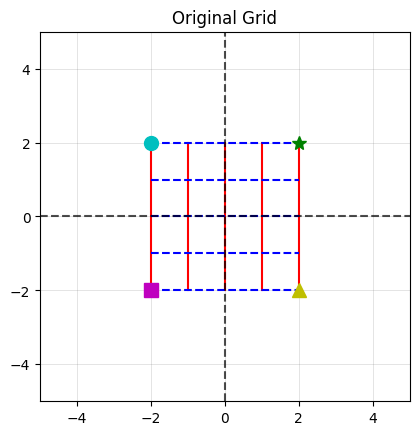

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Generate 1D arrays for x and y coordinates.
# np.arange(-2, 3, 1) creates an array [-2, -1, 0, 1, 2].
x = np.arange(-2,3,1)
y = np.arange(-2,3,1)


# Create a 2D grid from the 1D x and y arrays.
# X will contain all x-coordinates, Y will contain all y-coordinates.
X,Y = np.meshgrid(x,y)



# Create a figure with 3 subplots for original, T1-transformed, and T2-transformed grids.
# fig, axs = plt.subplots(1,3,figsize=(18,6))

# --- Plot 1: Original Grid ---
# Plot horizontal lines (red)
plt.plot(X,Y,'r')

# Plot vertical lines (blue, dashed). Transposing X and Y makes the columns into rows.
plt.plot(X.T,Y.T,'b--')

# Plot corner points of the original square for reference.
# These points are (2,2), (2,-2), (-2,2), (-2,-2).
plt.plot(2,2,'g*',ms=10)
plt.plot(2,-2,'y^',ms=10)
plt.plot(-2,2,'co',ms=10)
plt.plot(-2,-2,'ms',ms=10)

# Add dashed black lines for the x and y axes for clarity.
plt.axvline(x=0,
               linestyle='--',
               color='black',
               alpha=0.7)
plt.axhline(y=0,
               linestyle='--',
               color='black',
               alpha=0.7)

# Set the title and axis limits for the plot.
plt.title("Original Grid")
plt.xlim(-5,5)
plt.ylim(-5,5)

# Enable grid and ensure equal aspect ratio for accurate visualization.
plt.grid(True, color='gray', linewidth=0.5, alpha=0.3)

plt.gca().set_aspect('equal', adjustable='box')

# Show the plot.
plt.show()



## 4. Convert Grid into Coordinate Points

To apply matrix transformations, we need to convert our 2D grid arrays (`X`, `Y`) into a format suitable for matrix multiplication. This means flattening the arrays into 1D sequences and then stacking them to form a matrix of coordinate pairs.

#### Explanation of `flatten()`

`array.flatten()` is a NumPy method that returns a copy of the array collapsed into one dimension. For example, a 2x2 matrix will become a 1D array of 4 elements. This is useful for processing all x-coordinates or y-coordinates as a single list.

#### Explanation of `np.vstack()`

`np.vstack((array1, array2))` stacks arrays in sequence vertically (row-wise). If `array1` and `array2` are 1D arrays, `np.vstack` will combine them into a 2D array where `array1` forms the first row and `array2` forms the second. In our case, this creates a 2xN matrix where the first row contains all x-coordinates and the second row contains all y-coordinates of our grid points.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Generate 1D arrays for x and y coordinates.
# np.arange(-2, 3, 1) creates an array [-2, -1, 0, 1, 2].
x = np.arange(-2,3,1)
y = np.arange(-2,3,1)


# Create a 2D grid from the 1D x and y arrays.
# X will contain all x-coordinates, Y will contain all y-coordinates.
X,Y = np.meshgrid(x,y)

# Flatten the 2D X and Y grid arrays into 1D arrays.
# 'a' will contain all x-coordinates, 'b' will contain all y-coordinates.
a = X.flatten()
print(f"a = \n{a}\n")
b = Y.flatten()
print(f"b = \n{b}\n")

# Stack 'a' and 'b' vertically to create a 2xN matrix of points.
# Each column in 'points' represents a coordinate (x, y) from the grid.
points = np.vstack((a,b))
print(f"Points = \n{points}\n")

a = 
[-2 -1  0  1  2 -2 -1  0  1  2 -2 -1  0  1  2 -2 -1  0  1  2 -2 -1  0  1
  2]

b = 
[-2 -2 -2 -2 -2 -1 -1 -1 -1 -1  0  0  0  0  0  1  1  1  1  1  2  2  2  2
  2]

Points = 
[[-2 -1  0  1  2 -2 -1  0  1  2 -2 -1  0  1  2 -2 -1  0  1  2 -2 -1  0  1
   2]
 [-2 -2 -2 -2 -2 -1 -1 -1 -1 -1  0  0  0  0  0  1  1  1  1  1  2  2  2  2
   2]]



## 5. Apply Transformation T1 (Scaling)

Now we apply the scaling transformation matrix `T1` to every point in our grid. This operation will stretch the grid horizontally.

#### Geometric Explanation of Scaling

When `T1 = [[2, 0], [0, 1]]` is applied, every point $(x, y)$ on the grid is transformed to $(2x, y)$. This means that the x-coordinates are doubled, effectively stretching the entire grid horizontally away from the y-axis, while the vertical lines remain unchanged in their y-dimension. This causes a non-uniform deformation of the grid.

#### How Coordinate Points are Transformed

Each column vector $\mathbf{p} = \begin{bmatrix} x \\ y \end{bmatrix}$ in our `points` matrix is multiplied by `T1` to get a new transformed point $\mathbf{p}' = T1 \mathbf{p}$. Since `points` is a matrix where each column is a point, the matrix multiplication `T1 @ points` applies the transformation to all points simultaneously.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

T1 = np.array([[2,0],
               [0,1]])

# Generate 1D arrays for x and y coordinates.
# np.arange(-2, 3, 1) creates an array [-2, -1, 0, 1, 2].
x = np.arange(-2,3,1)
y = np.arange(-2,3,1)


# Create a 2D grid from the 1D x and y arrays.
# X will contain all x-coordinates, Y will contain all y-coordinates.
X,Y = np.meshgrid(x,y)

# Flatten the 2D X and Y grid arrays into 1D arrays.
# 'a' will contain all x-coordinates, 'b' will contain all y-coordinates.
a = X.flatten()
b = Y.flatten()

# Stack 'a' and 'b' vertically to create a 2xN matrix of points.
# Each column in 'points' represents a coordinate (x, y) from the grid.
points = np.vstack((a,b))

# Apply the transformation T1 to all grid points.
# The '@' operator performs matrix multiplication.
transformed_t1 = T1 @ points
print(f"After T1 Transformation = \n{transformed_t1}\n")

After T1 Transformation = 
[[-4 -2  0  2  4 -4 -2  0  2  4 -4 -2  0  2  4 -4 -2  0  2  4 -4 -2  0  2
   4]
 [-2 -2 -2 -2 -2 -1 -1 -1 -1 -1  0  0  0  0  0  1  1  1  1  1  2  2  2  2
   2]]



## 6. Reshape Transformed Coordinates

After applying the transformation, the `transformed_t1` matrix is a 2xN array of flattened coordinates. To plot these points as a grid, we need to reshape them back into their original 2D grid dimensions.

#### Explanation of `reshape()`

`array.reshape(shape)` is a NumPy method that gives a new shape to an array without changing its data. We use it to convert the 1D arrays of transformed x and y coordinates back into 2D arrays with the same dimensions as our original `X` and `Y` grid arrays. This allows Matplotlib to correctly draw the lines of the transformed grid.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

T1 = np.array([[2,0],
               [0,1]])

# Generate 1D arrays for x and y coordinates.
# np.arange(-2, 3, 1) creates an array [-2, -1, 0, 1, 2].
x = np.arange(-2,3,1)
y = np.arange(-2,3,1)


# Create a 2D grid from the 1D x and y arrays.
# X will contain all x-coordinates, Y will contain all y-coordinates.
X,Y = np.meshgrid(x,y)

# Flatten the 2D X and Y grid arrays into 1D arrays.
# 'a' will contain all x-coordinates, 'b' will contain all y-coordinates.
a = X.flatten()
b = Y.flatten()

# Stack 'a' and 'b' vertically to create a 2xN matrix of points.
# Each column in 'points' represents a coordinate (x, y) from the grid.
points = np.vstack((a,b))

# Apply the transformation T1 to all grid points.
# The '@' operator performs matrix multiplication.
transformed_t1 = T1 @ points

# Reshape the transformed x-coordinates back to the original grid shape.
X_t1 = transformed_t1[0,:].reshape(X.shape)
print(f"X_T1 = \n{X_t1}\n")
# Reshape the transformed y-coordinates back to the original grid shape.
Y_t1 = transformed_t1[1,:].reshape(Y.shape)
print(f"Y_T1 = \n{Y_t1}\n")

X_T1 = 
[[-4 -2  0  2  4]
 [-4 -2  0  2  4]
 [-4 -2  0  2  4]
 [-4 -2  0  2  4]
 [-4 -2  0  2  4]]

Y_T1 = 
[[-2 -2 -2 -2 -2]
 [-1 -1 -1 -1 -1]
 [ 0  0  0  0  0]
 [ 1  1  1  1  1]
 [ 2  2  2  2  2]]



## 7. Plot Transformed Grids (T1) and Corner Points

Now we can visualize the grid after applying the `T1` transformation. We will also plot the transformed corner points to clearly see the effect of the scaling.

#### Explanation of Plotting Transformed Grids

Just as with the original grid, we use `plot(X1_t1, Y1_t1, 'r')` for horizontal lines and `plot(X1_t1.T, Y1_t1.T, 'b--')` for vertical lines. The key difference is that `X1_t1` and `Y1_t1` now hold the *transformed* coordinates, visually demonstrating how `T1` has stretched the grid.

#### Explanation of Plotting Corner Points

Plotting specific, easily identifiable points (like the corners of the original square) helps to highlight the transformation's effect. By applying `T1` to these individual corner vectors and plotting their new positions, we can see exactly where these points end up after the scaling, reinforcing the visual deformation of the grid.

X_T1 = 
[[-4 -2  0  2  4]
 [-4 -2  0  2  4]
 [-4 -2  0  2  4]
 [-4 -2  0  2  4]
 [-4 -2  0  2  4]]

Y_T1 = 
[[-2 -2 -2 -2 -2]
 [-1 -1 -1 -1 -1]
 [ 0  0  0  0  0]
 [ 1  1  1  1  1]
 [ 2  2  2  2  2]]



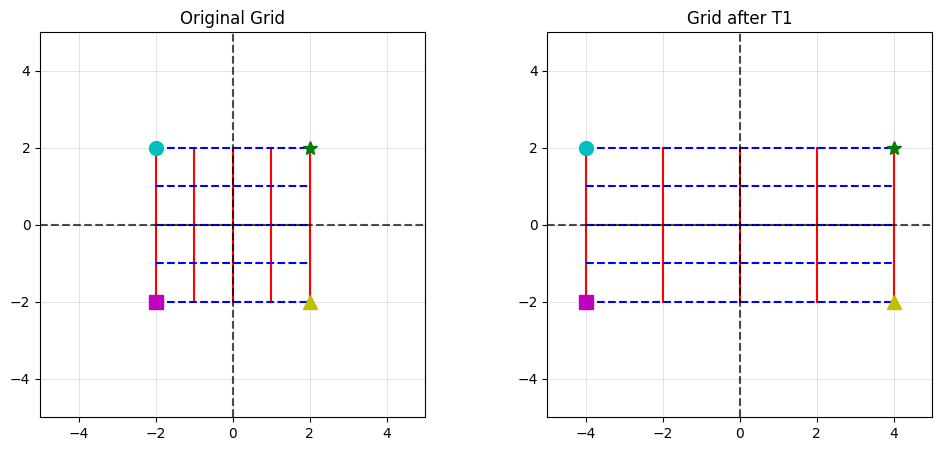

In [15]:
import numpy as np
import matplotlib.pyplot as plt

T1 = np.array([[2,0],
               [0,1]])

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
# Generate 1D arrays for x and y coordinates.
# np.arange(-2, 3, 1) creates an array [-2, -1, 0, 1, 2].
x = np.arange(-2,3,1)
y = np.arange(-2,3,1)


# Create a 2D grid from the 1D x and y arrays.
# X will contain all x-coordinates, Y will contain all y-coordinates.
X,Y = np.meshgrid(x,y)

# --- Plot 1: Original Grid ---
# Plot horizontal lines (red)
axs[0].plot(X,Y,'r')

# Plot vertical lines (blue, dashed). Transposing X and Y makes the columns into rows.
axs[0].plot(X.T,Y.T,'b--')

# Plot corner points of the original square for reference.
# These points are (2,2), (2,-2), (-2,2), (-2,-2).
axs[0].plot(2,2,'g*',ms=10)
axs[0].plot(2,-2,'y^',ms=10)
axs[0].plot(-2,2,'co',ms=10)
axs[0].plot(-2,-2,'ms',ms=10)

# Add dashed black lines for the x and y axes for clarity.
axs[0].axvline(x=0,
               linestyle='--',
               color='black',
               alpha=0.7)
axs[0].axhline(y=0,
               linestyle='--',
               color='black',
               alpha=0.7)

# Set the title and axis limits for the plot.
axs[0].set_title("Original Grid")
axs[0].set_xlim(-5,5)
axs[0].set_ylim(-5,5)

# Enable grid and ensure equal aspect ratio for accurate visualization.
axs[0].grid(True, color='gray', linewidth=0.5, alpha=0.3)
axs[0].set_aspect('equal')

# Flatten the 2D X and Y grid arrays into 1D arrays.
# 'a' will contain all x-coordinates, 'b' will contain all y-coordinates.
a = X.flatten()
b = Y.flatten()

# Stack 'a' and 'b' vertically to create a 2xN matrix of points.
# Each column in 'points' represents a coordinate (x, y) from the grid.
points = np.vstack((a,b))

# Apply the transformation T1 to all grid points.
# The '@' operator performs matrix multiplication.
transformed_t1 = T1 @ points

# Reshape the transformed x-coordinates back to the original grid shape.
X_t1 = transformed_t1[0,:].reshape(X.shape)
print(f"X_T1 = \n{X_t1}\n")
# Reshape the transformed y-coordinates back to the original grid shape.
Y_t1 = transformed_t1[1,:].reshape(Y.shape)
print(f"Y_T1 = \n{Y_t1}\n")

# --- Plot 2: Grid after T1 ---
# Plot horizontal lines of the T1-transformed grid (red).
axs[1].plot(X_t1,Y_t1,'r')

# Plot vertical lines of the T1-transformed grid (blue, dashed).
axs[1].plot(X_t1.T,Y_t1.T,'b--')

# Transform the original corner points using T1 and plot them.
# Original corners were (2,2), (2,-2), (-2,2), (-2,-2).
t1_corner_1 = T1 @ np.array([[2],[2]])
t1_corner_2 = T1 @ np.array([[2],[-2]])
t1_corner_3 = T1 @ np.array([[-2],[2]])
t1_corner_4 = T1 @ np.array([[-2],[-2]])



axs[1].plot(t1_corner_1[0],t1_corner_1[1],'g*',ms=10)
axs[1].plot(t1_corner_2[0],t1_corner_2[1],'y^',ms=10)
axs[1].plot(t1_corner_3[0],t1_corner_3[1],'co',ms=10)
axs[1].plot(t1_corner_4[0],t1_corner_4[1],'ms',ms=10)

# Add dashed black lines for the x and y axes.
axs[1].axvline(x=0,
               linestyle='--',
               color='black',
               alpha=0.7)
axs[1].axhline(y=0,
               linestyle='--',
               color='black',
               alpha=0.7)

# Set the title and axis limits for the plot.
axs[1].set_title("Grid after T1")
axs[1].set_xlim(-5,5)
axs[1].set_ylim(-5,5)

# Enable grid and ensure equal aspect ratio.
axs[1].grid(True, color='gray', linewidth=0.5, alpha=0.3)
axs[1].set_aspect('equal')

## 8. Apply Transformation T2 (Rotation)

Next, we apply the rotation transformation matrix `T2` to the *original* grid points. This will demonstrate how the grid rotates around the origin.

#### Geometric Explanation of Rotation

When `T2 = (1/sqrt(2)) * [[1, -1], [1, 1]]` is applied, every point $(x, y)$ on the grid is rotated by 45 degrees counter-clockwise around the origin. This transformation preserves distances and angles between points, meaning the grid will rotate as a whole without any stretching or shearing. The lines remain perpendicular and equally spaced, but their orientation changes.

In [16]:
import numpy as np
import matplotlib.pyplot as plt

T2 = (1/np.sqrt(2))*np.array([[1,-1],
                              [1, 1]])

# Generate 1D arrays for x and y coordinates.
# np.arange(-2, 3, 1) creates an array [-2, -1, 0, 1, 2].
x = np.arange(-2,3,1)
y = np.arange(-2,3,1)


# Create a 2D grid from the 1D x and y arrays.
# X will contain all x-coordinates, Y will contain all y-coordinates.
X,Y = np.meshgrid(x,y)

# Flatten the 2D X and Y grid arrays into 1D arrays.
# 'a' will contain all x-coordinates, 'b' will contain all y-coordinates.
a = X.flatten()
b = Y.flatten()

# Stack 'a' and 'b' vertically to create a 2xN matrix of points.
# Each column in 'points' represents a coordinate (x, y) from the grid.
points = np.vstack((a,b))

# Apply the transformation T2 to all original grid points.
# This performs a rotation on the entire grid.
transformed_t2 = T2 @ points

# Reshape the transformed x and y coordinates back to the original grid shape.
X1_t2 = transformed_t2[0,:].reshape(X.shape)
Y1_t2 = transformed_t2[1,:].reshape(Y.shape)

## 9. Plot Transformed Grids (T1) and Transformed Grids (T2) alongside original grid


T1 = 
[[2 0]
 [0 1]]

T2 = 
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]



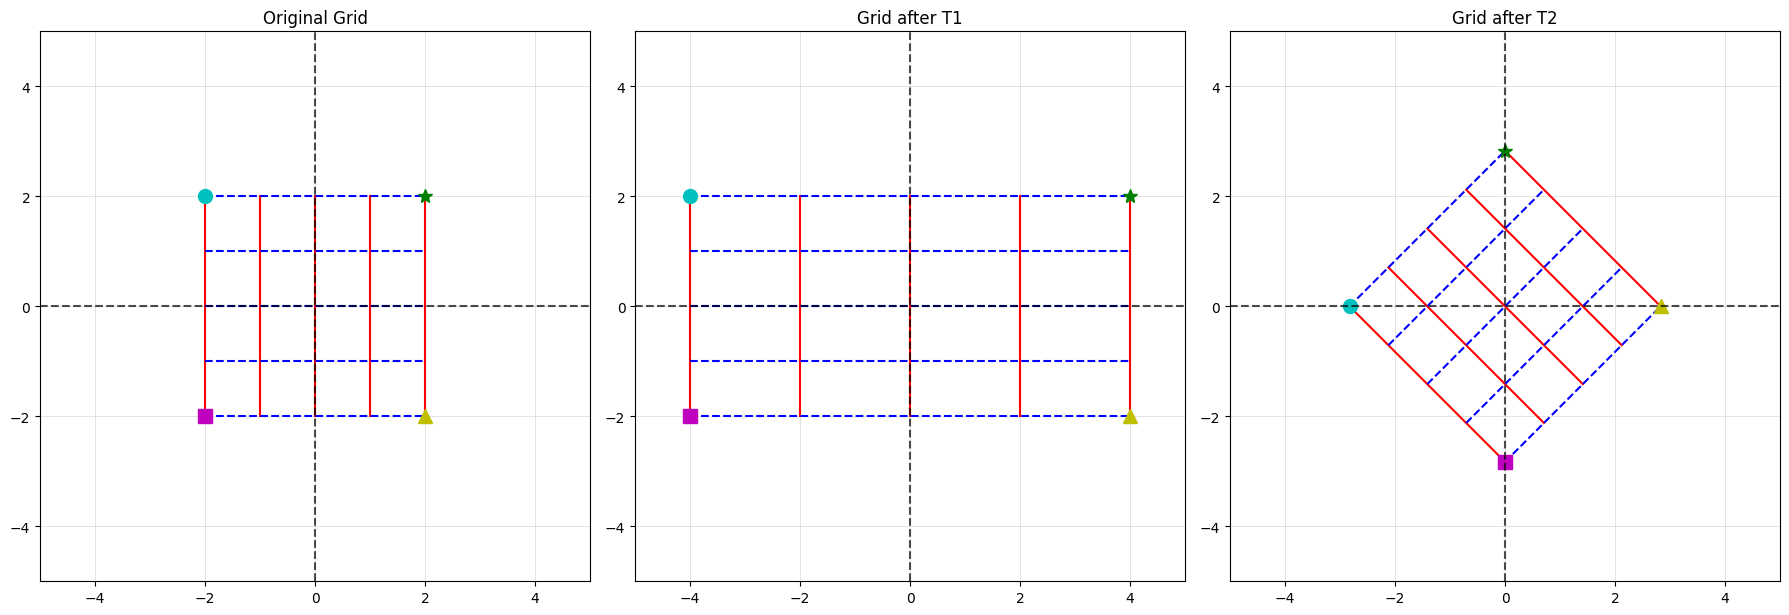

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Part B : Linear Transformations
# ==========================================================

# ----------------------------------------------------------
# Transformation Matrices
# ----------------------------------------------------------

T1 = np.array([[2,0],
               [0,1]])

T2 = (1/np.sqrt(2))*np.array([[1,-1],
                              [1, 1]])


print(f"T1 = \n{T1}\n")
print(f"T2 = \n{T2}\n")

# ----------------------------------------------------------
# Generate Input Grid
# ----------------------------------------------------------

x = np.arange(-2,3,1)
y = np.arange(-2,3,1)



X,Y = np.meshgrid(x,y)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

fig, axs = plt.subplots(1,3,figsize=(18,6))

# ==========================================================
# Plot 1 : Original Grid
# ==========================================================
# print(X)
# print(Y)
axs[0].plot(X,Y,'r')

axs[0].plot(X.T,Y.T,'b--')

axs[0].plot(2,2,'g*',ms=10)
axs[0].plot(2,-2,'y^',ms=10)
axs[0].plot(-2,2,'co',ms=10)
axs[0].plot(-2,-2,'ms',ms=10)

axs[0].axvline(x=0,
               linestyle='--',
               color='black',
               alpha=0.7)

axs[0].axhline(y=0,
               linestyle='--',
               color='black',
               alpha=0.7)

axs[0].set_title("Original Grid")
axs[0].set_xlim(-5,5)
axs[0].set_ylim(-5,5)
axs[0].grid(True, color='gray', linewidth=0.5, alpha=0.3)
axs[0].set_aspect('equal')

# ==========================================================
# Plot 2 : Grid after T1
# ==========================================================


a = X.flatten()
b = Y.flatten()

points = np.vstack((a,b))

transformed = T1 @ points
# print(transformed)
X1 = transformed[0,:].reshape(X.shape)
Y1 = transformed[1,:].reshape(Y.shape)
t1 = T1@np.array([[2],[2]])
t2 = T1@np.array([[2],[-2]])
t3 = T1@np.array([[-2],[2]])
t4 = T1@np.array([[-2],[-2]])

axs[1].plot(X1,Y1,'r')

axs[1].plot(X1.T,Y1.T,'b--')

axs[1].plot(t1[0],t1[1],'g*',ms=10)
axs[1].plot(t2[0],t2[1],'y^',ms=10)
axs[1].plot(t3[0],t3[1],'co',ms=10)
axs[1].plot(t4[0],t4[1],'ms',ms=10)


axs[1].axvline(x=0,
               linestyle='--',
               color='black',
               alpha=0.7)

axs[1].axhline(y=0,
               linestyle='--',
               color='black',
               alpha=0.7)

axs[1].set_title("Grid after T1")
axs[1].set_xlim(-5,5)
axs[1].set_ylim(-5,5)
axs[1].grid(True, color='gray', linewidth=0.5, alpha=0.3)
axs[1].set_aspect('equal')
# # ==========================================================
# # Plot 3 : Grid after T2
# # ==========================================================
transformed = T2 @ points
# print(transformed)
X1 = transformed[0,:].reshape(X.shape)
Y1 = transformed[1,:].reshape(Y.shape)
t1 = T2@np.array([[2],[2]])
t2 = T2@np.array([[2],[-2]])
t3 = T2@np.array([[-2],[2]])
t4 = T2@np.array([[-2],[-2]])

axs[2].plot(X1,Y1,'r')

axs[2].plot(X1.T,Y1.T,'b--')

axs[2].plot(t1[0],t1[1],'g*',ms=10)
axs[2].plot(t2[0],t2[1],'y^',ms=10)
axs[2].plot(t3[0],t3[1],'co',ms=10)
axs[2].plot(t4[0],t4[1],'ms',ms=10)

axs[2].axvline(x=0,
               linestyle='--',
               color='black',
               alpha=0.7)

axs[2].axhline(y=0,
               linestyle='--',
               color='black',
               alpha=0.7)

axs[2].set_title("Grid after T2")
axs[2].set_xlim(-5,5)
axs[2].set_ylim(-5,5)
axs[2].grid(True, color='gray', linewidth=0.5, alpha=0.3)
axs[2].set_aspect('equal')

plt.tight_layout()
plt.show()

## Conclusion: How Transformations Affect Geometry

Linear transformations, represented by matrix multiplication, are powerful tools to manipulate vectors and geometric spaces. They deform the space in predictable ways:

*   **Rotation**: Matrices can rotate objects around the origin without changing their size or shape (like `T2`). This preserves angles and distances.

*   **Scaling/Stretching**: Matrices can stretch or compress objects along specific axes (like `T1`). This changes the size of the object, often non-uniformly, but maintains the linearity of grid lines.

*   **Reflection**: Some matrices can reflect objects across an axis or plane.

*   **Shearing**: Matrices can also shear objects, skewing them so that parallel lines remain parallel but shift relative to each other.

In essence, transformation matrices provide a concise mathematical way to describe how points, vectors, and entire grids can be rotated, scaled, reflected, or sheared, forming the bedrock of computer graphics, physics simulations, and many other scientific and engineering applications.

## Practice Question for Students

Repeat parts (a) to (d) for the rotation transformation matrix

`R = [[cosθ,-sinθ],
      [sinθ, cosθ]]`

with

`θ = 60°`

Apply the rotation matrix to the grid and plot the transformed grid in a separate subplot.


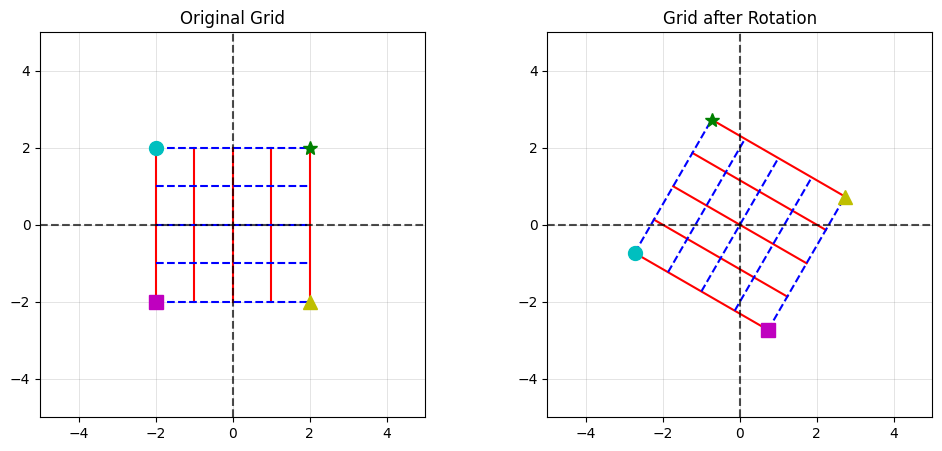

In [24]:
import numpy as np
from math import cos, sin

theta = 60

R = np.array([[cos(np.radians(theta)), -sin(np.radians(theta))],
              [sin(np.radians(theta)), cos(np.radians(theta))]])

# print(f"Rotation Matrix R for {theta} degrees = \n{R}\n")

# ----------------------------------------------------------
# Generate Input Grid
# ----------------------------------------------------------
x = np.arange(-2,3,1)
y = np.arange(-2,3,1)

X,Y = np.meshgrid(x,y)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Original Grid ---
# Plot horizontal lines (red)
axs[0].plot(X,Y,'r')

# Plot vertical lines (blue, dashed). Transposing X and Y makes the columns into rows.
axs[0].plot(X.T,Y.T,'b--')

# Plot corner points of the original square for reference.
# These points are (2,2), (2,-2), (-2,2), (-2,-2).
axs[0].plot(2,2,'g*',ms=10)
axs[0].plot(2,-2,'y^',ms=10)
axs[0].plot(-2,2,'co',ms=10)
axs[0].plot(-2,-2,'ms',ms=10)

# Add dashed black lines for the x and y axes for clarity.
axs[0].axvline(x=0,
               linestyle='--',
               color='black',
               alpha=0.7)
axs[0].axhline(y=0,
               linestyle='--',
               color='black',
               alpha=0.7)

# Set the title and axis limits for the plot.
axs[0].set_title("Original Grid")
axs[0].set_xlim(-5,5)
axs[0].set_ylim(-5,5)

# Enable grid and ensure equal aspect ratio for accurate visualization.
axs[0].grid(True, color='gray', linewidth=0.5, alpha=0.3)
axs[0].set_aspect('equal')

# Flatten the 2D X and Y grid arrays into 1D arrays.
# 'a' will contain all x-coordinates, 'b' will contain all y-coordinates.
a = X.flatten()
b = Y.flatten()

# Stack 'a' and 'b' vertically to create a 2xN matrix of points.
# Each column in 'points' represents a coordinate (x, y) from the grid.
points = np.vstack((a,b))

# Apply the transformation R to all grid points.
# The '@' operator performs matrix multiplication.
transformed_R = R @ points

# Reshape the transformed x-coordinates back to the original grid shape.
X_R = transformed_R[0,:].reshape(X.shape)
# print(f"X_R = \n{X_R}\n")

# Reshape the transformed y-coordinates back to the original grid shape.
Y_R = transformed_R[1,:].reshape(Y.shape)
# print(f"Y_R = \n{Y_R}\n")

# --- Plot 2: Grid after R ---
# Plot horizontal lines of the R-transformed grid (red).
axs[1].plot(X_R,Y_R,'r')

# Plot vertical lines of the R-transformed grid (blue, dashed).
axs[1].plot(X_R.T,Y_R.T,'b--')

# Transform the original corner points using R and plot them.
# Original corners were (2,2), (2,-2), (-2,2), (-2,-2).
r_corner_1 = R @ np.array([[2],[2]])
r_corner_2 = R @ np.array([[2],[-2]])
r_corner_3 = R @ np.array([[-2],[2]])
r_corner_4 = R @ np.array([[-2],[-2]])



axs[1].plot(r_corner_1[0],r_corner_1[1],'g*',ms=10)
axs[1].plot(r_corner_2[0],r_corner_2[1],'y^',ms=10)
axs[1].plot(r_corner_3[0],r_corner_3[1],'co',ms=10)
axs[1].plot(r_corner_4[0],r_corner_4[1],'ms',ms=10)

# Add dashed black lines for the x and y axes.
axs[1].axvline(x=0,
               linestyle='--',
               color='black',
               alpha=0.7)
axs[1].axhline(y=0,
               linestyle='--',
               color='black',
               alpha=0.7)

# Set the title and axis limits for the plot.
axs[1].set_title("Grid after Rotation")
axs[1].set_xlim(-5,5)
axs[1].set_ylim(-5,5)

# Enable grid and ensure equal aspect ratio.
axs[1].grid(True, color='gray', linewidth=0.5, alpha=0.3)
axs[1].set_aspect('equal')

# Part C: Composition of Linear Transformations

## Introduction to Composition

Just like with functions in algebra, linear transformations can be composed. This means applying one transformation after another. If we have two transformations, $T_1$ and $T_2$, applying $T_1$ first and then $T_2$ results in a composite transformation $T = T_2 \circ T_1$. When these transformations are represented by matrices $A_1$ and $A_2$, the composite transformation $T$ is represented by the matrix product $A_2 A_1$. This means $T(\mathbf{x}) = A_2(A_1\mathbf{x}) = (A_2A_1)\mathbf{x}$.

A crucial aspect of matrix multiplication (and thus, composition of linear transformations) is that it is generally **not commutative**. This means the order in which you apply the transformations matters: $A_1A_2 \neq A_2A_1$ in most cases. Geometrically, this means applying a rotation then a stretch is usually different from applying a stretch then a rotation.

### Definition of Transformation Matrices T3 and T4

For this section, we'll introduce two new transformation matrices:

*   **`T3` (Shear Transformation)**: `T3 = [[1, 1], [0, 1]]` is a shear matrix. When applied to a vector $(x, y)$, it transforms to $(x+y, y)$. This means the x-coordinate is shifted by an amount proportional to the y-coordinate, while the y-coordinate remains unchanged. Geometrically, this will skew the grid, making vertical lines slant.

*   **`T4` (Reflection Transformation)**: `T4 = [[-1, 0], [0, 1]]` is a reflection matrix. When applied to a vector $(x, y)$, it transforms to $(-x, y)$. This reflects the point across the y-axis (the x-coordinate is negated). Geometrically, this will flip the grid horizontally.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define a shear transformation matrix
# T3 shifts the x-coordinate by the y-coordinate (x+y, y)
T3 = np.array([[1, 1],
               [0, 1]])

# Define a reflection transformation matrix
# T4 reflects points across the y-axis (-x, y)
T4 = np.array([[-1, 0],
               [ 0, 1]])

print(f"T3 (Shear Matrix) = \n{T3}\n")
print(f"T4 (Reflection Matrix) = \n{T4}\n")

T3 (Shear Matrix) = 
[[1 1]
 [0 1]]

T4 (Reflection Matrix) = 
[[-1  0]
 [ 0  1]]



## 1. Composite Transformation T = T4 @ T3

To find the matrix that represents the composition of $T_3$ followed by $T_4$, we multiply their matrices. The order of matrix multiplication is important: if $T_3$ is applied first, then $T_4$, the composite matrix is $A_4 A_3$. Note that in mathematical notation, the transformation closest to the vector is applied first, so $T_4(T_3(\mathbf{x})) = (A_4 A_3)\mathbf{x}$.

#### Explanation of the `@` operator (revisited)

The `@` operator performs matrix multiplication. For $A_4 @ A_3$, it computes the product of matrix $A_4$ and matrix $A_3$. The resulting matrix will represent the combined effect of applying $A_3$ first, then $A_4$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define a shear transformation matrix
# T3 shifts the x-coordinate by the y-coordinate (x+y, y)
T3 = np.array([[1, 1],
               [0, 1]])

# Define a reflection transformation matrix
# T4 reflects points across the y-axis (-x, y)
T4 = np.array([[-1, 0],
               [ 0, 1]])

# Compute the composite transformation matrix T by multiplying T4 and T3.
# This represents applying T3 first, then T4.
T_composite = T4 @ T3

print(f"Composite Transformation T = T4T3 = \n{T_composite}\n")

Composite Transformation T = T4T3 = 
[[-1 -1]
 [ 0  1]]



## 2. Check Non-Commutativity

As mentioned, matrix multiplication is generally not commutative. Let's demonstrate this by calculating $T_3 T_4$ and comparing it to $T_4 T_3$ (which we called `T_composite`). If they are not equal, it proves that the order of transformations matters.

#### Explanation of `np.array_equal()`

`np.array_equal(array1, array2)` is a NumPy function that returns `True` if two arrays have the same shape and elements, and `False` otherwise. It's a reliable way to compare NumPy arrays element-wise.

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Define a shear transformation matrix
# T3 shifts the x-coordinate by the y-coordinate (x+y, y)
T3 = np.array([[1, 1],
               [0, 1]])

# Define a reflection transformation matrix
# T4 reflects points across the y-axis (-x, y)
T4 = np.array([[-1, 0],
               [ 0, 1]])

# Compute the composite transformation matrix T by multiplying T4 and T3.
# This represents applying T3 first, then T4.
T_composite = T4 @ T3

# Compute the reverse composite transformation matrix by multiplying T3 and T4.
# This represents applying T4 first, then T3.
T_reverse = T3 @ T4

print(f"T4T3 = \n{T_composite}\n")
print(f"T3T4 = \n{T_reverse}\n")

# Compare the two composite matrices to check for non-commutativity
if np.array_equal(T_composite, T_reverse):
    print("T4T3 = T3T4: The transformations are commutative.")
else:
    print("T4T3 ≠ T3T4: The transformations are NOT commutative. The order matters!")

T4T3 = 
[[-1 -1]
 [ 0  1]]

T3T4 = 
[[-1  1]
 [ 0  1]]

T4T3 ≠ T3T4: The transformations are NOT commutative. The order matters!


## 3. Visualization Setup for Composition

To visualize the original grid, and the effects of `T3`, `T4`, and their composite `T_composite` (T4T3), we'll create a figure with four subplots.

T3 = 
[[1 1]
 [0 1]]

T4 = 
[[-1  0]
 [ 0  1]]

T = T4T3 = 
[[-1 -1]
 [ 0  1]]

T4T3 = 
[[-1 -1]
 [ 0  1]]

T3T4 = 
[[-1  1]
 [ 0  1]]

T4T3 ≠ T3T4


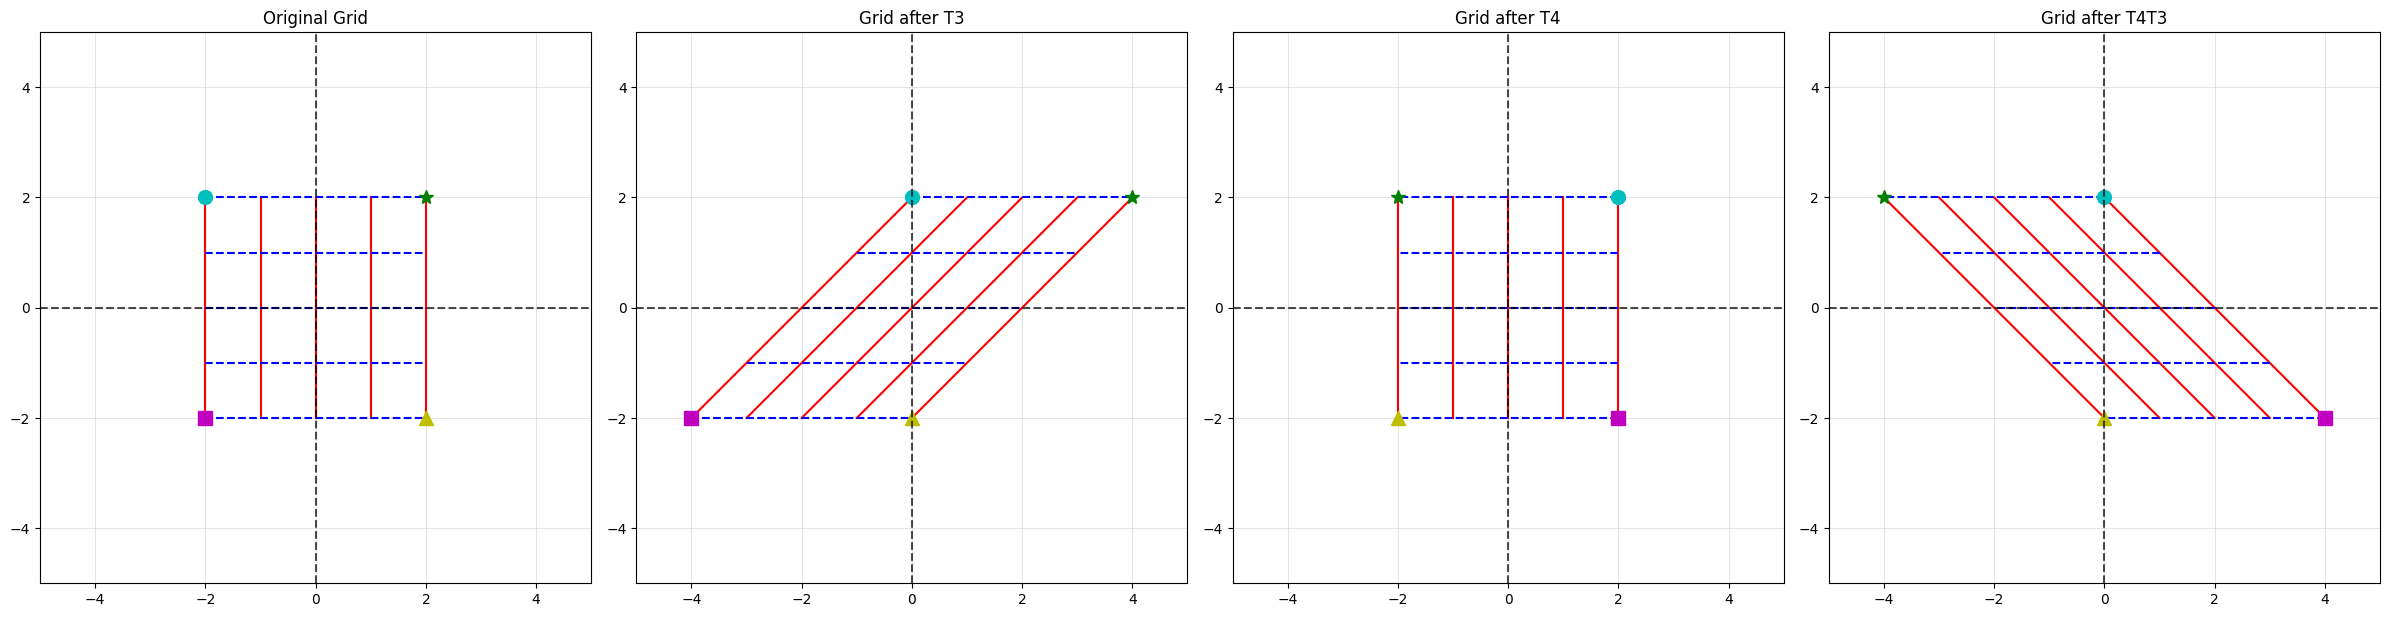

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Part C : Composition of Linear Transformations
# ==========================================================

# ----------------------------------------------------------
# Transformation Matrices
# ----------------------------------------------------------

T3 = np.array([[1, 1],
               [0, 1]])

T4 = np.array([[-1, 0],
               [ 0, 1]])

# ----------------------------------------------------------
# Composite Transformation
# ----------------------------------------------------------

T = T4 @ T3

print(f"T3 = \n{T3}\n")
print(f"T4 = \n{T4}\n")
print(f"T = T4T3 = \n{T}\n")

# ----------------------------------------------------------
# Check Non-Commutativity
# ----------------------------------------------------------

T_reverse = T3 @ T4

print(f"T4T3 = \n{T}\n")
print(f"T3T4 = \n{T_reverse}\n")

if np.array_equal(T, T_reverse):
    print("T4T3 = T3T4")
else:
    print("T4T3 ≠ T3T4")

# ----------------------------------------------------------
# Generate Input Grid
# ----------------------------------------------------------

x = np.arange(-2,3,1)
y = np.arange(-2,3,1)

X, Y = np.meshgrid(x,y)

# ----------------------------------------------------------
# Convert Grid Points into Matrix Form
# ----------------------------------------------------------

a = X.flatten()
b = Y.flatten()

points = np.vstack((a,b))

# ==========================================================
# Visualization
# ==========================================================

fig, axs = plt.subplots(1,4,figsize=(24,6))

# ==========================================================
# Plot 1 : Original Grid
# ==========================================================

axs[0].plot(X,Y,'r')

axs[0].plot(X.T,Y.T,'b--')

axs[0].plot(2,2,'g*',ms=10)
axs[0].plot(2,-2,'y^',ms=10)
axs[0].plot(-2,2,'co',ms=10)
axs[0].plot(-2,-2,'ms',ms=10)

axs[0].axvline(x=0,
               linestyle='--',
               color='black',
               alpha=0.7)

axs[0].axhline(y=0,
               linestyle='--',
               color='black',
               alpha=0.7)

axs[0].set_title("Original Grid")
axs[0].set_xlim(-5,5)
axs[0].set_ylim(-5,5)
axs[0].grid(True, color='gray', linewidth=0.5, alpha=0.3)
axs[0].set_aspect('equal')

# ==========================================================
# Plot 2 : Grid after T3
# ==========================================================

transformed = T3 @ points

X1 = transformed[0,:].reshape(X.shape)
Y1 = transformed[1,:].reshape(Y.shape)

t1 = T3 @ np.array([[2],[2]])
t2 = T3 @ np.array([[2],[-2]])
t3 = T3 @ np.array([[-2],[2]])
t4 = T3 @ np.array([[-2],[-2]])

axs[1].plot(X1,Y1,'r')

axs[1].plot(X1.T,Y1.T,'b--')

axs[1].plot(t1[0],t1[1],'g*',ms=10)
axs[1].plot(t2[0],t2[1],'y^',ms=10)
axs[1].plot(t3[0],t3[1],'co',ms=10)
axs[1].plot(t4[0],t4[1],'ms',ms=10)

axs[1].axvline(x=0,
               linestyle='--',
               color='black',
               alpha=0.7)

axs[1].axhline(y=0,
               linestyle='--',
               color='black',
               alpha=0.7)

axs[1].set_title("Grid after T3")
axs[1].set_xlim(-5,5)
axs[1].set_ylim(-5,5)
axs[1].grid(True, color='gray', linewidth=0.5, alpha=0.3)
axs[1].set_aspect('equal')

# ==========================================================
# Plot 3 : Grid after T4
# ==========================================================

transformed = T4 @ points

X1 = transformed[0,:].reshape(X.shape)
Y1 = transformed[1,:].reshape(Y.shape)

t1 = T4 @ np.array([[2],[2]])
t2 = T4 @ np.array([[2],[-2]])
t3 = T4 @ np.array([[-2],[2]])
t4 = T4 @ np.array([[-2],[-2]])

axs[2].plot(X1,Y1,'r')

axs[2].plot(X1.T,Y1.T,'b--')

axs[2].plot(t1[0],t1[1],'g*',ms=10)
axs[2].plot(t2[0],t2[1],'y^',ms=10)
axs[2].plot(t3[0],t3[1],'co',ms=10)
axs[2].plot(t4[0],t4[1],'ms',ms=10)

axs[2].axvline(x=0,
               linestyle='--',
               color='black',
               alpha=0.7)

axs[2].axhline(y=0,
               linestyle='--',
               color='black',
               alpha=0.7)

axs[2].set_title("Grid after T4")
axs[2].set_xlim(-5,5)
axs[2].set_ylim(-5,5)
axs[2].grid(True, color='gray', linewidth=0.5, alpha=0.3)
axs[2].set_aspect('equal')

# ==========================================================
# Plot 4 : Grid after T4T3
# ==========================================================

transformed = T @ points

X1 = transformed[0,:].reshape(X.shape)
Y1 = transformed[1,:].reshape(Y.shape)

t1 = T @ np.array([[2],[2]])
t2 = T @ np.array([[2],[-2]])
t3 = T @ np.array([[-2],[2]])
t4 = T @ np.array([[-2],[-2]])

axs[3].plot(X1,Y1,'r')

axs[3].plot(X1.T,Y1.T,'b--')

axs[3].plot(t1[0],t1[1],'g*',ms=10)
axs[3].plot(t2[0],t2[1],'y^',ms=10)
axs[3].plot(t3[0],t3[1],'co',ms=10)
axs[3].plot(t4[0],t4[1],'ms',ms=10)

axs[3].axvline(x=0,
               linestyle='--',
               color='black',
               alpha=0.7)

axs[3].axhline(y=0,
               linestyle='--',
               color='black',
               alpha=0.7)

axs[3].set_title("Grid after T4T3")
axs[3].set_xlim(-5,5)
axs[3].set_ylim(-5,5)
axs[3].grid(True, color='gray', linewidth=0.5, alpha=0.3)
axs[3].set_aspect('equal')

plt.tight_layout()
plt.show()



## Conclusion : Non-Commutativity and Combined Effects

This section vividly demonstrates that the order of linear transformations matters. Applying a shear then a reflection (`T4T3`) yields a different result than applying a reflection then a shear (`T3T4`). This non-commutative property is fundamental in linear algebra and has significant implications in fields like computer graphics, where the sequence of operations (e.g., rotating an object then translating it versus translating then rotating) directly affects the final position and orientation of objects.

Each transformation matrix represents a specific geometric action. By composing them, we can achieve complex transformations that are combinations of these basic actions. Understanding how these compositions work is key to manipulating objects and spaces in a controlled and predictable manner.

## Overall Final Conclusion: How Transformations Affect Geometry

Linear transformations, represented by matrix multiplication, are powerful tools to manipulate vectors and geometric spaces. They deform the space in predictable ways:

*   **Rotation**: Matrices can rotate objects around the origin without changing their size or shape. This preserves angles and distances.

*   **Scaling/Stretching**: Matrices can stretch or compress objects along specific axes. This changes the size of the object, often non-uniformly, but maintains the linearity of grid lines.

*   **Reflection**: Some matrices can reflect objects across an axis or plane, effectively mirroring them.

*   **Shearing**: Matrices can also shear objects, skewing them so that parallel lines remain parallel but shift relative to each other.

Through the exploration of these concepts and their visualization on grids, we've seen how matrices can rotate, stretch, reflect, or shear vectors and entire grids. In essence, transformation matrices provide a concise mathematical way to describe how points, vectors, and entire grids can be manipulated, forming the bedrock of computer graphics, physics simulations, and many other scientific and engineering applications.

## Practice Question for Students

Repeat parts (a) to (d) using the following transformation matrices:

`T5 = (1/√2) [[1,-1],
              [1, 1]]`

and

`T6 = [[1, 0],
       [0,-1]]`

Apply the transformations to the grid and plot the transformed grids in separate subplots.



In [ ]:
# Type your code here

# Part D : Image Transformation

This section demonstrates how linear transformations, specifically rotations, can be applied to digital images using NumPy for matrix operations and OpenCV for image handling. We will implement rotation by manually performing inverse pixel mapping, which involves calculating the source pixel for each destination pixel using inverse transformation matrices.

## 1. Import Libraries and Mount Google Drive

We begin by importing all necessary Python libraries for numerical operations, plotting, image processing, and Google Drive integration.

### Explanation of Functions:

*   **`from PIL import Image`**: Imports the `Image` module from the Pillow (PIL) library, which is a powerful image processing library. Although `cv2.imread` is used here, Pillow offers alternative image manipulation capabilities.
*   **`import cv2`**: Imports the OpenCV library, a widely used library for computer vision tasks, including image loading, manipulation, and transformations.
*   **`from google.colab import drive`**: Imports the `drive` module from `google.colab`, which provides functionality to mount Google Drive in the Colab environment.
*   **`drive.mount('/content/drive')`**: This function call mounts your Google Drive to the `/content/drive` directory within the Colab virtual machine. This makes files in your Google Drive accessible to your Python code as if they were on the local file system.

In [ ]:
# ==========================================================
# Import Libraries
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

from google.colab import drive

# ==========================================================
# Mount Google Drive
# ==========================================================

drive.mount('/content/drive')

## 2. Read Image

In this section, we load an image from Google Drive, convert its color format, and extract its dimensions (height and width).


### Explanation of Functions:

*   **`cv2.imread(path)`**: This OpenCV function reads an image from the specified file `path` and returns it as a NumPy array. By default, it reads images in BGR color order.
*   **`cv2.cvtColor(img, cv2.COLOR_BGR2RGB)`**: This OpenCV function converts an image from one color space to another. Here, `cv2.COLOR_BGR2RGB` specifies the conversion from BGR (OpenCV's default) to RGB (Matplotlib's default).
*   **`img.shape[:2]`**: The `shape` attribute of a NumPy array returns a tuple representing the dimensions of the array. For an image, `img.shape` is typically `(height, width, color_channels)`. Slicing `[:2]` extracts the first two elements, which correspond to the `height` and `width` of the image.

In [26]:
# ==========================================================
# Import Libraries
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

# from google.colab import drive

# ==========================================================
# Mount Google Drive
# ==========================================================

# drive.mount('/content/drive')
# ==========================================================
# Part A : Read Image
# ==========================================================

# ----------------------------------------------------------
# Read Image from Google Drive
# ----------------------------------------------------------

path = "./Lab1_Img.jpg"

img1 = cv2.imread(path)


# ----------------------------------------------------------
# Convert BGR to RGB
# ----------------------------------------------------------

img = cv2.cvtColor(img1,
                   cv2.COLOR_BGR2RGB)

# ----------------------------------------------------------
# Get Image Dimensions
# ----------------------------------------------------------

h, w = img.shape[:2]

print(f"Height = {h}")
print(f"Width  = {w}\n")

Height = 341
Width  = 500



## 3. Create Coordinate Grid

 We generate a grid of coordinates representing every pixel in the image. This grid is then flattened and stacked into a 2xN matrix, where N is the total number of pixels.


### Mathematical Meaning:

Each pixel in an image can be identified by its $(x, y)$ coordinates. The standard coordinate system for images usually starts with $(0,0)$ at the top-left corner. By generating `X` and `Y` meshgrids, we are essentially creating a matrix where each element $(i, j)$ in `X` is the x-coordinate and `Y` is the y-coordinate of the pixel at row $i$ and column $j$.

When we stack them using `np.vstack`, we create a single matrix `P` of shape $2 \times (w \times h)$, where each column $\mathbf{p}_k = \begin{bmatrix} x_k \ y_k \end{bmatrix}$ represents a pixel's coordinates:

$$ \mathbf{P} = \begin{bmatrix} x_0 & x_1 & \dots & x_{wh-1} \\ y_0 & y_1 & \dots & y_{wh-1} \end{bmatrix} $$

### Explanation of Functions:

*   **`np.arange(start, stop)`**: Creates a 1D NumPy array with evenly spaced values within a given interval. Here, `np.arange(0, w)` generates `[0, 1, ..., w-1]` for x-coordinates, and `np.arange(0, h)` generates `[0, 1, ..., h-1]` for y-coordinates.
*   **`np.meshgrid(x, y)`**: Returns two 2D arrays, `X` and `Y`, which can be used to create a grid of coordinates. `X` will have rows where values are constant, and `Y` will have columns where values are constant. Each pair `(X[i,j], Y[i,j])` forms a unique coordinate on the grid.
*   **`array.flatten()`**: Returns a copy of the array collapsed into one dimension. This transforms the 2D `X` and `Y` arrays into 1D sequences of all x- and y-coordinates, respectively.
*   **`np.vstack((array1, array2))`**: Stacks arrays in sequence vertically (row-wise). It takes a tuple of arrays and returns a single array with the input arrays stacked as rows.

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2


path = "./Lab1_Img.jpg"

img1 = cv2.imread(path)


img = cv2.cvtColor(img1,
                   cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]

# ==========================================================
# Part B : Create Coordinate Grid
# ==========================================================

# ----------------------------------------------------------
# Create Coordinate Axes
# ----------------------------------------------------------

x = np.arange(0,w)

y = np.arange(0,h)


# ----------------------------------------------------------
# Create Meshgrid
# ----------------------------------------------------------

X, Y = np.meshgrid(x,y)

# ----------------------------------------------------------
# Convert Grid into Point Matrix
# ----------------------------------------------------------

a = X.flatten()

b = Y.flatten()

points = np.vstack((a,b))

print(f"Points Shape = {points.shape}\n")

Points Shape = (2, 170500)



## 4. Shift Coordinates to Center

We adjust the coordinates of all pixels so that the origin (0,0) is moved from the top-left corner of the image to its geometric center.

### Mathematical Meaning:

If an original pixel coordinate is $\mathbf{p} = \begin{bmatrix} x \\ y \end{bmatrix}$ and the image center is $(c_x, c_y)$, the shifted coordinate $\mathbf{p}'$ is given by:

$$ \mathbf{p}' = \mathbf{p} - \begin{bmatrix} c_x \\ c_y \end{bmatrix} = \begin{bmatrix} x - c_x \\ y - c_y \end{bmatrix} $$

This is a simple vector subtraction that translates all points such that the point $(c_x, c_y)$ becomes $(0,0)$.

### Geometric Interpretation:

Imagine the image on a Cartesian plane. Initially, the point $(0,0)$ is at the top-left. When we shift the coordinates, we are essentially moving the entire image so that its exact center aligns with the origin of the coordinate system. This is a crucial preprocessing step for transformations that naturally operate around the origin, such as pure rotations or scaling from the center.

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2


path = "./Lab1_Img.jpg"

img1 = cv2.imread(path)


img = cv2.cvtColor(img1,
                   cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]


x = np.arange(0,w)

y = np.arange(0,h)


X, Y = np.meshgrid(x,y)

a = X.flatten()

b = Y.flatten()

points = np.vstack((a,b))

# ==========================================================
# Part C : Shift Coordinates to Center
# ==========================================================

# ----------------------------------------------------------
# Compute Image Center
# ----------------------------------------------------------

cx = w/2

cy = h/2

print(f"Center = ({cx},{cy})\n")

# ----------------------------------------------------------
# Shift Coordinates
# ----------------------------------------------------------

shifted_points = points.copy()

shifted_points[0,:] = shifted_points[0,:] - cx

shifted_points[1,:] = shifted_points[1,:] - cy

Center = (250.0,170.5)



## 5. Transformation Matrices

We define a 2x2 transformation matrix (`T1`) that represents a 90-degree counter-clockwise rotation.

### Mathematical Meaning:

A 2D rotation matrix `R` for a counter-clockwise rotation by an angle $\theta$ around the origin is given by:

$$ R(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix} $$

For a 90-degree rotation ($\theta = 90^\circ = \pi/2$ radians):

$\cos(90^\circ) = 0$

$\sin(90^\circ) = 1$

Substituting these values, the matrix `T1` becomes:

$$ \mathbf{T1} = \begin{bmatrix} 0 & -1 \\ 1 & 0 \end{bmatrix} $$

When this matrix multiplies a vector $\begin{bmatrix} x \\ y \end{bmatrix}$, it transforms to $\begin{bmatrix} -y \\ x \end{bmatrix}$, which is indeed a 90-degree counter-clockwise rotation.

### Explanation of Functions:

*   **`np.radians(degrees)`**: Converts an angle from degrees to radians. This is necessary because `np.cos` and `np.sin` functions expect their input in radians.
*   **`np.cos(angle)`**: Computes the cosine of the given `angle` (in radians).
*   **`np.sin(angle)`**: Computes the sine of the given `angle` (in radians).

In [ ]:
# ==========================================================
# Part D : Transformation Matrices
# ==========================================================

# ----------------------------------------------------------
# Rotation by 90 Degrees
# ----------------------------------------------------------

theta = np.radians(90)

# ----------------------------------------------------------
# Transformation Matrix T1
# ----------------------------------------------------------

T1 = np.array([[np.cos(theta), -np.sin(theta)],
               [np.sin(theta),  np.cos(theta)]])

print(f"T1 = \n{T1}\n")

T1 = 
[[ 6.123234e-17 -1.000000e+00]
 [ 1.000000e+00  6.123234e-17]]



## 6. Composite Transformations

We create transformation matrices for 180, 270, and 360-degree rotations by composing the 90-degree rotation matrix (`T1`) with itself.

### Mathematical Meaning:

If $\mathbf{R}_{90}$ is the matrix for a 90-degree rotation, then:

*   180-degree rotation: $\mathbf{R}_{180} = \mathbf{R}_{90} \mathbf{R}_{90} = \mathbf{R}_{90}^2$
*   270-degree rotation: $\mathbf{R}_{270} = \mathbf{R}_{90} \mathbf{R}_{90} \mathbf{R}_{90} = \mathbf{R}_{90}^3$
*   360-degree rotation: $\mathbf{R}_{360} = \mathbf{R}_{90} \mathbf{R}_{90} \mathbf{R}_{90} \mathbf{R}_{90} = \mathbf{R}_{90}^4$

Specifically:

$$ \mathbf{T2} = \begin{bmatrix} 0 & -1 \\ 1 & 0 \end{bmatrix} \begin{bmatrix} 0 & -1 \\ 1 & 0 \end{bmatrix} = \begin{bmatrix} -1 & 0 \\ 0 & -1 \end{bmatrix} $$

This matrix transforms $\begin{bmatrix} x \\ y \end{bmatrix}$ to $\begin{bmatrix} -x \\ -y \end{bmatrix}$, which is a 180-degree rotation.

$$ \mathbf{T3} = \begin{bmatrix} -1 & 0 \\ 0 & -1 \end{bmatrix} \begin{bmatrix} 0 & -1 \\ 1 & 0 \end{bmatrix} = \begin{bmatrix} 0 & 1 \\ -1 & 0 \end{bmatrix} $$

This matrix transforms $\begin{bmatrix} x \\ y \end{bmatrix}$ to $\begin{bmatrix} y \\ -x \end{bmatrix}$, a 270-degree rotation.

$$ \mathbf{T4} = \begin{bmatrix} 0 & 1 \\ -1 & 0 \end{bmatrix} \begin{bmatrix} 0 & -1 \\ 1 & 0 \end{bmatrix} = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix} $$

This matrix transforms $\begin{bmatrix} x \\ y \end{bmatrix}$ to $\begin{bmatrix} x \\ y \end{bmatrix}$, the identity transformation, which corresponds to a 360-degree rotation.

### Linear Algebra Concepts:

This section highlights the non-commutative property of matrix multiplication when dealing with different types of transformations, but for rotations around the same center, it is commutative. It also shows how repeated application of a transformation is equivalent to raising its matrix to a power. The `@` operator is used for matrix multiplication.

In [ ]:
# ==========================================================
# Part E : Composite Transformations
# ==========================================================

# ----------------------------------------------------------
# T1T1 = Rotation by 180 Degrees
# ----------------------------------------------------------

T2 = T1 @ T1

print(f"T2 = T1T1 = \n{T2}\n")

# ----------------------------------------------------------
# T1T1T1 = Rotation by 270 Degrees
# ----------------------------------------------------------

T3 = T1 @ T1 @ T1

print(f"T3 = T1T1T1 = \n{T3}\n")

# ----------------------------------------------------------
# T1T1T1T1 = Rotation by 360 Degrees
# ----------------------------------------------------------

T4 = T1 @ T1 @ T1 @ T1

print(f"T4 = T1T1T1T1 = \n{T4}\n")

T2 = T1T1 = 
[[-1.0000000e+00 -1.2246468e-16]
 [ 1.2246468e-16 -1.0000000e+00]]

T3 = T1T1T1 = 
[[-1.8369702e-16  1.0000000e+00]
 [-1.0000000e+00 -1.8369702e-16]]

T4 = T1T1T1T1 = 
[[ 1.0000000e+00  2.4492936e-16]
 [-2.4492936e-16  1.0000000e+00]]



## 7. Create Empty Output Images

**What we are going to do:** We create several empty NumPy arrays, each with the same dimensions and data type as the original image. These arrays will serve as canvases for our transformed images.

**Why this section is needed:** When performing image transformations by manually mapping pixels, we need a blank image where we can 'draw' the transformed pixels. Since we're rotating the image into new arrays, we need to initialize these arrays to hold the output.

**The logic behind this part of the code:** `np.zeros_like(img)` is called four times, once for each rotation (90, 180, 270, and 360 degrees). Each call creates an array filled with zeros (which represents black color in RGB) that has the identical shape and data type as the `img` array.

### Explanation of Function:

*   **`np.zeros_like(array)`**: This NumPy function returns a new array of zeros with the same shape and data type as a given array (`img` in this case). It's a convenient way to create an empty canvas that perfectly matches the input image's characteristics.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2


path = "./Lab1_Img.jpg"

img1 = cv2.imread(path)


img = cv2.cvtColor(img1,
                   cv2.COLOR_BGR2RGB)


# ==========================================================
# Part F : Create Empty Output Images
# ==========================================================

rot90_img  = np.zeros_like(img)

rot180_img = np.zeros_like(img)

rot270_img = np.zeros_like(img)

rot360_img = np.zeros_like(img)

## 8. Forward Pixel Mapping

We iterate through every pixel in the *original* image, apply the transformation matrices to compute their new positions in the transformed image, and then copy the pixel values to those new coordinates.

This is the core algorithm for applying geometric transformations using forward mapping.

In forward mapping:
- source pixels are pushed toward new transformed locations
- the transformation matrix directly computes the destination coordinates

Example:

`p_new = T @ p_old`

However, because transformed coordinates may become non-integer values, rounding is required. This can sometimes cause:
- overlapping pixels
- missing destination pixels
- small gaps or holes in the transformed image

especially during rotations and scaling operations.

**The logic behind this part of the code:**
1.  **Outer Loops:** Two nested `for` loops iterate through every `(x_new, y_new)` coordinate in the output image (from 0 to `w-1` for x, and 0 to `h-1` for y).
2.  **Shift Coordinates to Center:** For each `(x_new, y_new)` output pixel, we first shift its coordinates relative to the image center: `x_shift = x_new - cx`, `y_shift = y_new - cy`. This is because our rotation matrices (`T1`, `T2`, etc.) perform rotations around the origin, and the origin is currently at the center of the image.
3. **Apply Transformation:** For each shifted input pixel `(x_shift, y_shift)`, we multiply it by the transformation matrix (e.g., `T1` for 90-degree rotation) to compute its new transformed coordinates.

   Example:

   `source90 = T1 @ np.array([[x_shift], [y_shift]])`

   This gives the transformed coordinates `(x_new_shifted, y_new_shifted)` in the rotated coordinate system, while still keeping the origin at the image center.
4.  **Shift Coordinates Back:** The `source` coordinates are then shifted back to the original top-left origin by adding `cx` and `cy`: `xs = int(round(source90[0,0] + cx))`, `ys = int(round(source90[1,0] + cy))`. The `round()` function ensures we get integer pixel coordinates, and `int()` converts them.
5.  **Boundary Check:** An `if` condition `(0 <= xs < w) and (0 <= ys < h)` checks if the calculated source coordinates `(xs, ys)` fall within the bounds of the original image. This prevents `IndexError` if the transformation maps a pixel outside the original image.
6.  **Pixel Copying:** If the source coordinates are valid, the color value of the pixel at `(ys, xs)` from the original `img` is copied to the current output pixel `(y_new, x_new)` in the respective rotated image (e.g., `rot90_img`).
7.  This entire process is repeated for each of the four rotation matrices (T1, T2, T3, T4).



In [30]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2


path = "./Lab1_Img.jpg"

img1 = cv2.imread(path)


img = cv2.cvtColor(img1,
                   cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]


x = np.arange(0,w)

y = np.arange(0,h)


X, Y = np.meshgrid(x,y)

a = X.flatten()

b = Y.flatten()

points = np.vstack((a,b))

cx = w/2

cy = h/2

print(f"Center = ({cx},{cy})\n")


shifted_points = points.copy()

shifted_points[0,:] = shifted_points[0,:] - cx

shifted_points[1,:] = shifted_points[1,:] - cy

theta = np.radians(90)

T1 = np.array([[np.cos(theta), -np.sin(theta)],
               [np.sin(theta),  np.cos(theta)]])

T2 = T1 @ T1


T3 = T1 @ T1 @ T1


T4 = T1 @ T1 @ T1 @ T1


rot90_img  = np.zeros_like(img)

rot180_img = np.zeros_like(img)

rot270_img = np.zeros_like(img)

rot360_img = np.zeros_like(img)


# ==========================================================
# Part H : Inverse Pixel Mapping
# ==========================================================

# ----------------------------------------------------------
# Loop through Output Image Pixels
# ----------------------------------------------------------

for y_new in range(h):

    for x_new in range(w):

        # --------------------------------------------------
        # Shift Coordinates to Center
        # --------------------------------------------------

        x_shift = x_new - cx

        y_shift = y_new - cy

        # ==================================================
        # Rotation by 90 Degrees
        # ==================================================

        source90 = T1 @ np.array([[x_shift],
                                      [y_shift]])

        xs = int(round(source90[0,0] + cx))

        ys = int(round(source90[1,0] + cy))

        if (0 <= xs < w) and (0 <= ys < h):

            rot90_img[y_new,
                      x_new] = img[ys,
                                   xs]

        # ==================================================
        # Rotation by 180 Degrees
        # ==================================================

        source180 = T2 @ np.array([[x_shift],
                                       [y_shift]])

        xs = int(round(source180[0,0] + cx))

        ys = int(round(source180[1,0] + cy))

        if (0 <= xs < w) and (0 <= ys < h):

            rot180_img[y_new,
                       x_new] = img[ys,
                                    xs]

        # ==================================================
        # Rotation by 270 Degrees
        # ==================================================

        source270 = T3 @ np.array([[x_shift],
                                       [y_shift]])

        xs = int(round(source270[0,0] + cx))

        ys = int(round(source270[1,0] + cy))

        if (0 <= xs < w) and (0 <= ys < h):

            rot270_img[y_new,
                       x_new] = img[ys,
                                    xs]

        # ==================================================
        # Rotation by 360 Degrees
        # ==================================================

        source360 = T4 @ np.array([[x_shift],
                                       [y_shift]])

        xs = int(round(source360[0,0] + cx))

        ys = int(round(source360[1,0] + cy))

        if (0 <= xs < w) and (0 <= ys < h):

            rot360_img[y_new,
                       x_new] = img[ys,
                                    xs]

Center = (250.0,170.5)



## 19. Visualization

**What we are going to do:** We display the original image alongside its rotated versions using Matplotlib.


### Explanation of Functions:

*   **`plt.subplots(nrows, ncols, figsize=(width, height))`**: Creates a figure and a set of subplots. `nrows` and `ncols` specify the grid dimensions, and `figsize` sets the size of the overall figure in inches.
*   **`axs[index].imshow(image_data)`**: Displays image data (a NumPy array) on the axes object at the given `index`. Matplotlib automatically scales the image and handles color mapping.
*   **`axs[index].set_title("Title Text")`**: Sets the title for the individual subplot represented by `axs[index]`.
*   **`axs[index].axis('off')`**: Turns off the axis lines, ticks, and labels for the current subplot, making the image display cleaner.
*   **`plt.tight_layout()`**: Automatically adjusts subplot parameters to give a tight layout. This helps prevent overlap between subplots.
*   **`plt.show()`**: Displays all open Matplotlib figures.

Height = 341
Width  = 500

Points Shape = (2, 170500)

Center = (250.0,170.5)

T1 = 
[[ 6.123234e-17 -1.000000e+00]
 [ 1.000000e+00  6.123234e-17]]

T2 = T1T1 = 
[[-1.0000000e+00 -1.2246468e-16]
 [ 1.2246468e-16 -1.0000000e+00]]

T3 = T1T1T1 = 
[[-1.8369702e-16  1.0000000e+00]
 [-1.0000000e+00 -1.8369702e-16]]

T4 = T1T1T1T1 = 
[[ 1.0000000e+00  2.4492936e-16]
 [-2.4492936e-16  1.0000000e+00]]



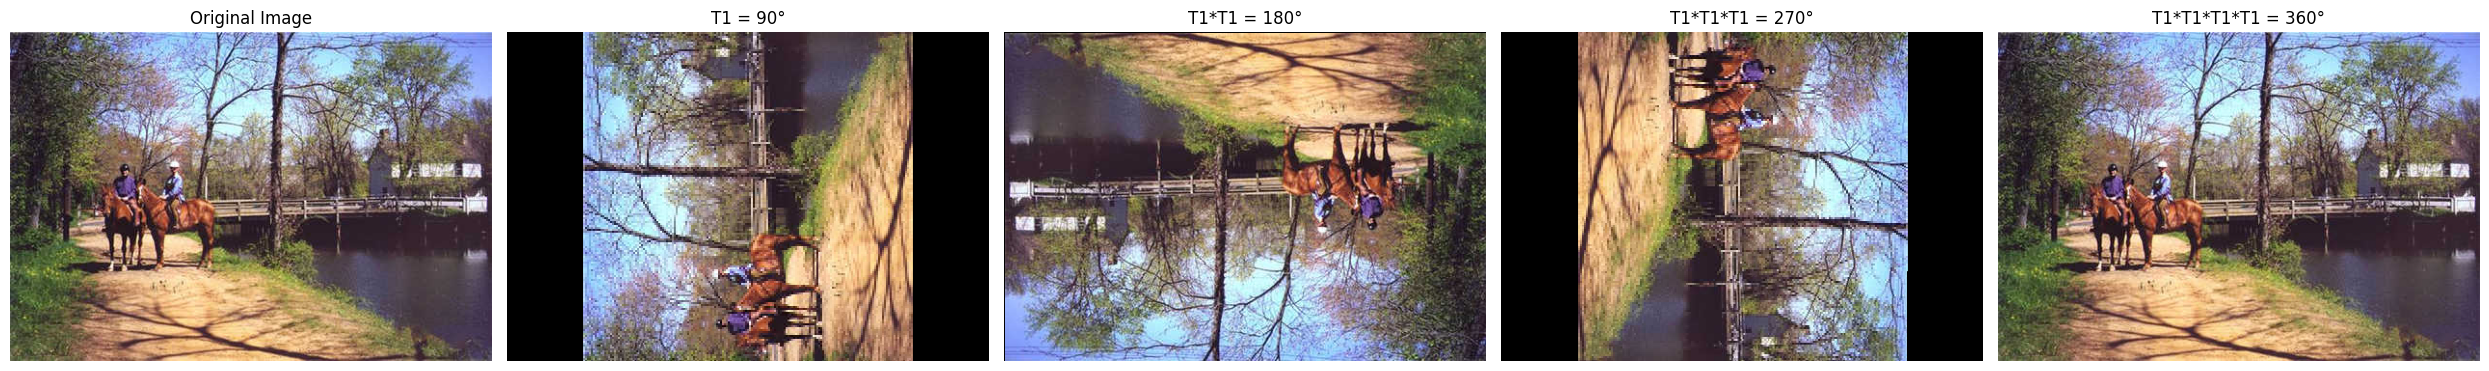

In [31]:
# ==========================================================
# Import Libraries
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

# ==========================================================
# Part A : Read Image
# ==========================================================

# ----------------------------------------------------------
# Read Image from Google Drive
# ----------------------------------------------------------

path = "./Lab1_Img.jpg"

img = cv2.imread(path)

# ----------------------------------------------------------
# Convert BGR to RGB
# ----------------------------------------------------------

img = cv2.cvtColor(img,
                   cv2.COLOR_BGR2RGB)

# ----------------------------------------------------------
# Convert Image into NumPy Array
# ----------------------------------------------------------

# img = np.array(img)

# ----------------------------------------------------------
# Get Image Dimensions
# ----------------------------------------------------------

h, w = img.shape[:2]

print(f"Height = {h}")
print(f"Width  = {w}\n")

# ==========================================================
# Part B : Create Coordinate Grid
# ==========================================================

# ----------------------------------------------------------
# Create Coordinate Axes
# ----------------------------------------------------------

x = np.arange(0,w)

y = np.arange(0,h)

# ----------------------------------------------------------
# Create Meshgrid
# ----------------------------------------------------------

X, Y = np.meshgrid(x,y)

# ----------------------------------------------------------
# Convert Grid into Point Matrix
# ----------------------------------------------------------

a = X.flatten()

b = Y.flatten()

points = np.vstack((a,b))

print(f"Points Shape = {points.shape}\n")

# ==========================================================
# Part C : Shift Coordinates to Center
# ==========================================================

# ----------------------------------------------------------
# Compute Image Center
# ----------------------------------------------------------

cx = w/2

cy = h/2

print(f"Center = ({cx},{cy})\n")

# ----------------------------------------------------------
# Shift Coordinates
# ----------------------------------------------------------

shifted_points = points.copy()

shifted_points[0,:] = shifted_points[0,:] - cx

shifted_points[1,:] = shifted_points[1,:] - cy

# ==========================================================
# Part D : Transformation Matrices
# ==========================================================

# ----------------------------------------------------------
# Rotation by 90 Degrees
# ----------------------------------------------------------

theta = np.radians(90)

# ----------------------------------------------------------
# Transformation Matrix T1
# ----------------------------------------------------------

T1 = np.array([[np.cos(theta), -np.sin(theta)],
               [np.sin(theta),  np.cos(theta)]])

print(f"T1 = \n{T1}\n")

# ==========================================================
# Part E : Composite Transformations
# ==========================================================

# ----------------------------------------------------------
# T1T1 = Rotation by 180 Degrees
# ----------------------------------------------------------

T2 = T1 @ T1

print(f"T2 = T1T1 = \n{T2}\n")

# ----------------------------------------------------------
# T1T1T1 = Rotation by 270 Degrees
# ----------------------------------------------------------

T3 = T1 @ T1 @ T1

print(f"T3 = T1T1T1 = \n{T3}\n")

# ----------------------------------------------------------
# T1T1T1T1 = Rotation by 360 Degrees
# ----------------------------------------------------------

T4 = T1 @ T1 @ T1 @ T1

print(f"T4 = T1T1T1T1 = \n{T4}\n")

# ==========================================================
# Part F : Create Empty Output Images
# ==========================================================

rot90_img  = np.zeros_like(img)

rot180_img = np.zeros_like(img)

rot270_img = np.zeros_like(img)

rot360_img = np.zeros_like(img)



# ----------------------------------------------------------
# Loop through Output Image Pixels
# ----------------------------------------------------------

for y_new in range(h):

    for x_new in range(w):

        # --------------------------------------------------
        # Shift Coordinates to Center
        # --------------------------------------------------

        x_shift = x_new - cx

        y_shift = y_new - cy

        # ==================================================
        # Rotation by 90 Degrees
        # ==================================================

        source90 = T1 @ np.array([[x_shift],
                                      [y_shift]])


        xs = int(round(source90[0,0] + cx))

        ys = int(round(source90[1,0] + cy))

        if (0 <= xs < w) and (0 <= ys < h):

            rot90_img[y_new,
                      x_new] = img[ys,
                                   xs]

        # ==================================================
        # Rotation by 180 Degrees
        # ==================================================

        source180 = T2 @ np.array([[x_shift],
                                       [y_shift]])

        xs = int(round(source180[0,0] + cx))

        ys = int(round(source180[1,0] + cy))

        if (0 <= xs < w) and (0 <= ys < h):

            rot180_img[y_new,
                       x_new] = img[ys,
                                    xs]

        # ==================================================
        # Rotation by 270 Degrees
        # ==================================================

        source270 = T3 @ np.array([[x_shift],
                                       [y_shift]])

        xs = int(round(source270[0,0] + cx))

        ys = int(round(source270[1,0] + cy))

        if (0 <= xs < w) and (0 <= ys < h):

            rot270_img[y_new,
                       x_new] = img[ys,
                                    xs]

        # ==================================================
        # Rotation by 360 Degrees
        # ==================================================

        source360 = T4 @ np.array([[x_shift],
                                       [y_shift]])

        xs = int(round(source360[0,0] + cx))

        ys = int(round(source360[1,0] + cy))

        if (0 <= xs < w) and (0 <= ys < h):

            rot360_img[y_new,
                       x_new] = img[ys,
                                    xs]

# ==========================================================
# Visualization
# ==========================================================

fig, axs = plt.subplots(1,
                        5,
                        figsize=(25,6))

# ==========================================================
# Plot 1 : Original Image
# ==========================================================

axs[0].imshow(img)

axs[0].set_title("Original Image")

axs[0].axis('off')

# ==========================================================
# Plot 2 : T1 = 90 Degrees
# ==========================================================

axs[1].imshow(rot90_img)

axs[1].set_title("T1 = 90°")

axs[1].axis('off')

# ==========================================================
# Plot 3 : T1*T1 = 180 Degrees
# ==========================================================

axs[2].imshow(rot180_img)

axs[2].set_title("T1*T1 = 180°")

axs[2].axis('off')

# ==========================================================
# Plot 4 : T1*T1*T1 = 270 Degrees
# ==========================================================

axs[3].imshow(rot270_img)

axs[3].set_title("T1*T1*T1 = 270°")

axs[3].axis('off')

# ==========================================================
# Plot 5 : T1*T1*T1*T1 = 360 Degrees
# ==========================================================

axs[4].imshow(rot360_img)

axs[4].set_title("T1*T1*T1*T1 = 360°")

axs[4].axis('off')

# ==========================================================
# Display Results
# ==========================================================

plt.tight_layout()

plt.show()

